# TrainPeaknet

Goal:
- Train a model to convert noisy spectra to clean spectra



## Step 1 - Imports

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from tqdm import tqdm
from datetime import datetime

# Check PyTorch and CUDA availability
print('Torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Torch version: 2.12.0+cu130
CUDA available: True


## Step 2 - Paths

Setting the paths to the datasets to be used for training

In [2]:
base_dir = os.getcwd()
data_dir = os.path.join(base_dir, '../Data/dataset_big')

print('Base dir:', base_dir)
print('Peaks dir:', data_dir)

Base dir: /home/exxley/Documents/Peaknet/Models
Peaks dir: /home/exxley/Documents/Peaknet/Models/../Data/dataset_big


## Step 3 - Load the numpy arrays
Loading in the peaks and noise data then concatinating it


In [3]:
# Load the spectra and masks
peak_spectra = np.load(os.path.join(data_dir, 'peaks_spectra.npy'), allow_pickle=True)
peak_masks = np.load(os.path.join(data_dir, 'peaks_masks.npy'), allow_pickle=True)

# Load noise spectra and masks
noise_spectra = np.load(os.path.join(data_dir, 'noise_spectra.npy'), allow_pickle=True)
noise_masks = np.load(os.path.join(data_dir, 'noise_masks.npy'), allow_pickle=True)

# Return the shape of the loaded datasets
print('Peak spectra shape :', peak_spectra.shape)
print('Peak masks shape   :', peak_masks.shape)
print('Noise spectra shape:', noise_spectra.shape)
print('Noise masks shape  :', noise_masks.shape)


Peak spectra shape : (1000000,)
Peak masks shape   : (1000000,)
Noise spectra shape: (50000,)
Noise masks shape  : (50000,)


## Step 4 - Clip values into a sensible range

I clip the spectra between -0.2 and 1.

This is done because real spectra/noise can dip below 0, but I still want to stop extreme values from getting too large.

The masks stay between 0 and 1 because the target peak shape should not be negative.


In [4]:
def clip_spectra_array_inplace(array, low, high):
    # Clip each spectrum in place, one element at a time, instead of building
    # a whole second array of clipped copies. Building a second array meant
    # briefly holding both the original and clipped versions of the entire
    # (very large) dataset in memory at once, which is what was causing the
    # process to run out of RAM and get killed by the OS.
    for i in range(len(array)):
        array[i] = np.clip(array[i], low, high).astype(np.float32)
    return array

# Clip peaks and noise separately, before combining them, so we never need
# more than one extra array's worth of memory at a time
peak_spectra = clip_spectra_array_inplace(peak_spectra, -0.2, 1.0)
peak_masks = clip_spectra_array_inplace(peak_masks, 0.0, 1.0)
noise_spectra = clip_spectra_array_inplace(noise_spectra, -0.2, 1.0)
noise_masks = clip_spectra_array_inplace(noise_masks, 0.0, 1.0)

# Combine peaks and noise, deleting the separate arrays as soon as each
# combined array is built instead of keeping every intermediate alive at once
spectra = np.concatenate([peak_spectra, noise_spectra], axis=0)
del peak_spectra, noise_spectra

masks = np.concatenate([peak_masks, noise_masks], axis=0)
del peak_masks, noise_masks

print('Combined spectra shape:', spectra.shape)
print('Combined masks shape  :', masks.shape)

# Check that they have the same shape
assert spectra.shape == masks.shape, 'The spectra and masks must have the same shape'

# Spectra and masks are ragged lists so I must use loops to find the min and max values
print('Spectra min/max:', min(s.min() for s in spectra), max(s.max() for s in spectra))
print('Masks min/max  :', min(m.min() for m in masks), max(m.max() for m in masks))


Combined spectra shape: (1050000,)
Combined masks shape  : (1050000,)
Spectra min/max: -0.2 1.0
Masks min/max  : 0.0 1.0


## Step 5 - Add a channel dimension

The spectra start as:

`(number of spectra, spectrum length)`

But a PyTorch `Conv1d` layer expects:

`(number of spectra, channels, spectrum length)`

My spectra only have one channel, so I add a middle dimension of size 1.


In [5]:
class SpectraDataset(Dataset):
    def __init__(self, spectra, masks):
        # Store spectra and masks as lists because they can have different lengths
        self.spectra = spectra
        self.masks = masks

    # Used later when Dataloader calls len(dataset) to return the size of the dataset
    def __len__(self):
        return len(self.spectra)

    # Used by the DataLoader to get the actual data when iterating over batches
    def __getitem__(self, index):
        # Convert one spectrum and mask to tensors when they are requested
        # Spectra[index] is a array of shape (L,) and [None,:] adds a new axis to make it (1, L)
        # It does the same as .reshap(1, L) but [None,:] works on ragged arrays 
        spectrum = torch.tensor(self.spectra[index][None, :], dtype=torch.float32)
        mask = torch.tensor(self.masks[index][None, :], dtype=torch.float32)
        return spectrum, mask




## Step 6 - Make a PyTorch dataset

Each item in the dataset contains a spectrum and a target mask

In [6]:
# Create the dataset by calling the class 
dataset = SpectraDataset(spectra, masks)
print('Total examples  :', len(dataset))

# Get the first two examples from the dataset and print their shapes
one_x, one_y = dataset[0]
print('One input shape :', one_x.shape)
print('One target shape:', one_y.shape)


two_x, two_y = dataset[1]
print('Two input shape :', two_x.shape)
print('Two target shape:', two_y.shape)


Total examples  : 1050000
One input shape : torch.Size([1, 1750])
One target shape: torch.Size([1, 1750])
Two input shape : torch.Size([1, 266])
Two target shape: torch.Size([1, 266])


## Step 7 - Split into training and validation data

The training set is used to update the model.

The validation set is kept separate, so I can check whether the model is learning something useful instead of only memorising the training data.

I use an 80/20 split for this first attempt.


In [7]:
# Setting the validation fraction
validation_fraction = 0.2

# A random seed is needed for a torch Generator to ensure that the split is reproducible
random_seed = 88

# Setting the number of validation and training examples based on the validation fraction
n_val = int(validation_fraction * len(dataset))
n_train = len(dataset) - n_val

# Split the dataset into training and validation sets using random_split
# The torch generator means giving it the same random seed will produce the same 
# set of "random" numbers each time 
generator = torch.Generator().manual_seed(random_seed)
# Performing the split using the set of "random" numbers from the generator
train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=generator
)

print('Training examples  :', len(train_dataset))
print('Validation examples:', len(val_dataset))


Training examples  : 840000
Validation examples: 210000


## Step 8 - Make DataLoaders

The `DataLoader` gives the model a batch of spectra at a time.
This is better than training on one spectrum at a time because it is faster and gives a more stable estimate of the error.

For each batch the longest spectra is found and the rest are padded to be the length of the longest spectra.


I shuffle the training loader so the model does not see the data in the same order every epoch.


In [8]:
batch_size = 16

def collate_spectra(batch):
    # Split the batch into spectra and masks
    # zip does spectra = [b[0] for b in batch]; masks = [b[1] for b in batch] in one go
    spectra, masks = zip(*batch)

    # Find the longest spectrum in this batch
    lengths = torch.tensor([spectrum.shape[-1] for spectrum in spectra])
    longest_length = int(lengths.max())

    # Make empty padded tensors i.e [0,0,0,0,0,0,0] for each spectra up to longest_length
    padded_spectra = torch.zeros(len(batch), 1, longest_length)
    padded_masks = torch.zeros(len(batch), 1, longest_length)
    valid_bins = torch.zeros(len(batch), 1, longest_length)

    # Copy each spectrum into the padded batch
    # Placing the original spectrum into the padded tensor and leaving the rest as zeros
    # TODO consider the fact that they are all added at the start of the tensor
    # for example addings [3,7,8] to [0,0,0,0,0,0,0] would result in [3,7,8,0,0,0,0]
    for i, (spectrum, mask) in enumerate(zip(spectra, masks)):
        L = spectrum.shape[-1]
        padded_spectra[i, :, :L] = spectrum
        padded_masks[i, :, :L] = mask
        valid_bins[i, :, :L] = 1.0

    return padded_spectra, padded_masks, valid_bins

# Calling the DataLoader with the collate function to handle variable-length spectra
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_spectra)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_spectra)

# Pulling out one batch of the training data loader to check shapes
xb, yb, valid_bins = next(iter(train_loader))
print('Batch input shape :', xb.shape)
print('Batch target shape:', yb.shape)
print('Valid bins shape  :', valid_bins.shape)


Batch input shape : torch.Size([16, 1, 3985])
Batch target shape: torch.Size([16, 1, 3985])
Valid bins shape  : torch.Size([16, 1, 3985])


## Step 9 - Building Peaknet model

I use `Conv1d` because a spectrum is a 1D signal, and peaks are local shapes across neighbouring bins.

The model is:
- convolution layer to detect local patterns 
- ReLU activation to add non-linearity
- another convolution to build better features
- final convolution to return one output value per bin

The kernel size is set to 51 since some of the peaks can be quite large (up to a few hundred out of 4096), padding is set to half that value - 1.
output_length = input_length + 2*padding - kernel_size + 1
The output has the same length as the input because I use padding.


In [9]:
class Peaknet(nn.Module):
    def __init__(self):
        # Using super so that the model initialises correctly 
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=27, padding=13, padding_mode='replicate'),
            nn.ReLU(),
            nn.Conv1d(32, 32, kernel_size=27, padding=13, padding_mode='replicate'),
            nn.ReLU(),
            nn.Conv1d(32, 1, kernel_size=27, padding=13, padding_mode='replicate'),
            # Sigmoid squashes the output into [0, 1] to match the mask range
            nn.Sigmoid(),
        )
    # Calling Peaknet.forward(spectra) will pass the input through the network
    def forward(self, x):
        return self.net(x)

# Calling the model to check it initializes correctly
model = Peaknet()
# Check the model architecture 
model

Peaknet(
  (net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(27,), stride=(1,), padding=(13,), padding_mode=replicate)
    (1): ReLU()
    (2): Conv1d(32, 32, kernel_size=(27,), stride=(1,), padding=(13,), padding_mode=replicate)
    (3): ReLU()
    (4): Conv1d(32, 1, kernel_size=(27,), stride=(1,), padding=(13,), padding_mode=replicate)
    (5): Sigmoid()
  )
)

## Step 10 - Check the model output shape

Before training, I want to check that the model accepts a batch and returns the right shape.

This is useful because shape mistakes are one of the most common problems in PyTorch.


In [10]:
# Using the single batch from before, check model output shape
test_output = model(xb)

print('Input shape :', xb.shape)
print('Output shape:', test_output.shape)
print('Target shape:', yb.shape)


Input shape : torch.Size([16, 1, 3985])
Output shape: torch.Size([16, 1, 3985])
Target shape: torch.Size([16, 1, 3985])


## Step 11 - Choose device, loss function, and optimiser

The device is either GPU or CPU.

The loss function measures how wrong the model is. I use mean squared error because this is a regression problem: the model predicts a continuous curve, not a class label.

The optimiser updates the model weights. I use Adam because it is a good standard starting point.


In [11]:
# Set the device, either GPU if available or CPU otherwise
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move the model to the device
model = Peaknet().to(device)

# This is MSE, but only on real bins rather than padded bins
def masked_mse_loss(prediction, target, valid_bins):
    # Work out the squared error
    error = (prediction - target) ** 2
    # Remove the padded region from the loss
    error = error * valid_bins
    # Average over the real bins only
    return error.sum() / valid_bins.sum().clamp_min(1.0)

# This extra loss punishes the model if it predicts values below 0
def negative_prediction_loss(prediction, valid_bins):
    # Get pred value, flip its sign, if it is neg it becomes 0 when relu acts on it 
    negative_part = torch.relu(-prediction)
    # Only count real bins, not padded bins
    loss = (negative_part ** 2) * valid_bins
    # Return the mean loss over real bins
    return loss.sum() / valid_bins.sum().clamp_min(1.0)

# This compares the slope of the prediction to the slope of the target mask
def slope_shape_loss(prediction, target, valid_bins, width=1):
    # Skip this loss if the spectrum is too short for this width
    if prediction.shape[-1] <= width:
        return prediction.new_tensor(0.0)
    # (batch, channel, length), so width controls how many bins apart the slope is measured
    # width=1 compares neighbouring bins, width=10 compares bins 10 apart
    pred_slope = prediction[:, :, width:] - prediction[:, :, :-width]
    target_slope = target[:, :, width:] - target[:, :, :-width]
    # Only count slopes where both bins are real
    slope_bins = valid_bins[:, :, width:] * valid_bins[:, :, :-width]
    error = ((pred_slope - target_slope) ** 2) * slope_bins
    return error.sum() / slope_bins.sum().clamp_min(1.0)

# This compares how the slope changes, which helps remove bumpy shapes
def curvature_shape_loss(prediction, target, valid_bins, width=1):
    # Skip this loss if the spectrum is too short for this width
    if prediction.shape[-1] <= 2 * width:
        return prediction.new_tensor(0.0)
    # Getting the slopes again
    pred_slope = prediction[:, :, width:] - prediction[:, :, :-width]
    target_slope = target[:, :, width:] - target[:, :, :-width]
    # This time finding the differences in the slopes, which is the curvature
    pred_curvature = pred_slope[:, :, width:] - pred_slope[:, :, :-width]
    target_curvature = target_slope[:, :, width:] - target_slope[:, :, :-width]
    # Only count curvature values where the needed bins are real
    curvature_bins = valid_bins[:, :, 2 * width:] * valid_bins[:, :, width:-width] * valid_bins[:, :, :-2 * width]
    error = ((pred_curvature - target_curvature) ** 2) * curvature_bins
    return error.sum() / curvature_bins.sum().clamp_min(1.0)

# Set optimizer as Adam with learning rate of 1e-4 
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler: halve the LR whenever the validation loss stops
# improving for 3 epochs in a row, so the model can take careful smaller
# steps as it gets closer to the best weights
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3)

print('Using device:', device)

Using device: cuda


## Step 12 - One training step slowly

This is the basic learning process and important to remember:

1. Move ONE batch to the device
2. Clear old gradients
3. Predict the mask
4. Compare prediction to the real mask
5. Backpropagate the loss
6. Update the model weights

I write it once by itself so the full loop makes more sense.


In [12]:
# iter to batch one dataset in at a time and next to ask for the batch from the dataloader
xb, yb, valid_bins = next(iter(train_loader))

# Moving the batch to the same device as the model 
xb = xb.to(device)
yb = yb.to(device)
valid_bins = valid_bins.to(device)

# Clear the last gradients
optimizer.zero_grad()

# Forward pass
prediction = model(xb)

# Compute the normal MSE loss
mse_loss = masked_mse_loss(prediction, yb, valid_bins)

# Set weightings 
mse_loss_weight = 3
negative_prediction_weight = 5
small_slope_shape_weight = 5.0
medium_slope_shape_weight = 15
large_slope_shape_weight = 25

small_curvature_shape_weight = 5.0
medium_curvature_shape_weight = 20
large_curvature_shape_weight = 30

small_shape_width = 1
medium_shape_width = 10
large_shape_width = 50


# Compute the extra loss for negative predictions
negative_loss = negative_prediction_loss(prediction, valid_bins)

# Compute losses for matching the peak shape at small, medium, and large bin widths
small_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=small_shape_width)
medium_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=medium_shape_width)
large_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=large_shape_width)
small_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=small_shape_width)
medium_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=medium_shape_width)
large_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=large_shape_width)

# Total loss combines all parts
loss = (
    mse_loss * mse_loss_weight
    + negative_prediction_weight * negative_loss
    + small_slope_shape_weight * small_slope_loss
    + medium_slope_shape_weight * medium_slope_loss
    + large_slope_shape_weight * large_slope_loss
    + small_curvature_shape_weight * small_curvature_loss
    + medium_curvature_shape_weight * medium_curvature_loss
    + large_curvature_shape_weight * large_curvature_loss
)

# Output the individual loss components and the total loss before the backward pass
print('MSE loss:', float(mse_loss.detach()))
print('Negative prediction loss:', float(negative_loss.detach()))
print('Small slope shape loss:', float(small_slope_loss.detach()))
print('Medium slope shape loss:', float(medium_slope_loss.detach()))
print('Large slope shape loss:', float(large_slope_loss.detach()))
print('Small curvature shape loss:', float(small_curvature_loss.detach()))
print('Medium curvature shape loss:', float(medium_curvature_loss.detach()))
print('Large curvature shape loss:', float(large_curvature_loss.detach()))
print('Total loss before update:', float(loss.detach()))

# Backward pass and compute the gradients
loss.backward()

# Update the gradients
optimizer.step()


MSE loss: 0.18106800317764282
Negative prediction loss: 0.0
Small slope shape loss: 0.00010891893180087209
Medium slope shape loss: 0.003055392764508724
Large slope shape loss: 0.01797972060739994
Small curvature shape loss: 6.85069608152844e-05
Medium curvature shape loss: 0.0053316568955779076
Large curvature shape loss: 0.03706803545355797
Total loss before update: 2.258089303970337


## Step 13 - Train for several epochs

Each epoch is one full pass through the training dataset

For each epoch:

First do training:
- set the model to training mode
- set the train loss to 0
- iterate over the training data in batches
- send batch to device
- clear the gradients
- make a prediction
- calculate losses
- combine losses into single loss
- backwards pass the loss
- update the weights using optimizer
- append loss * batch size to training losses
- average training loss over entire dataset 

Then do evaluation:
- set the model to evaluation mode
- set the validation loss to 0
- call torch no grad so it doesn't compute new gradients
- iterate over the evaluationn data in batches
- send batch to device
- make a prediction 
- calculate losses
- combine to single loss
- append loss * batch size to validation losses
- average the validation loss over the entire dataset

Finally:
- scheduler then looks at the validation loss and adjust the learning rate 
- record the training and validation loss for this epoch
- save the model it the validation loss is best so far

? why only when the validation loss is best so far ?
Well the model can start to memorise examples from the training set and so it can 
become to used to them and think it knows the answer, this is overfitting

If both losses go down, that is a good first sign that the model is learning. If the
validation loss consistently goes down then the model is working.


In [13]:
# Set the number of epochs to train for
epochs = 60

# Make a dictionary to store the training and validation loss history for each epoch
history = {
    'train_loss': [],
    'val_loss': [],
}

# Setup dir for model saving
checkpoint_dir = os.path.join(base_dir, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

# Keep track of the best validation loss seen so far
best_val_loss = float('inf')
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
best_checkpoint_path = os.path.join(checkpoint_dir, f'peaknet_{timestamp}.pth')

for epoch in range(epochs):

    # Set the model to training mode (good practice to do this at the start of each epoch)
    model.train()

    # Set the loss to 0 at the start of each epoch
    train_loss = 0.0

    # Iterate over the training data (this is the previous step but now for the whole dataset in batches)
    for xb, yb, valid_bins in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}'):

        # Move the batches to the device
        xb = xb.to(device)
        yb = yb.to(device)
        valid_bins = valid_bins.to(device)

        # Clear the gradients
        optimizer.zero_grad()

        # Make prediction 
        prediction = model(xb)

        # Compute the normal MSE loss
        mse_loss = masked_mse_loss(prediction, yb, valid_bins)

        # Add a penalty if the model predicts below 0
        negative_loss = negative_prediction_loss(prediction, valid_bins)

        # Add shape losses at small, medium, and large bin widths
        small_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=small_shape_width)
        medium_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=medium_shape_width)
        large_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=large_shape_width)
        small_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=small_shape_width)
        medium_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=medium_shape_width)
        large_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=large_shape_width)

        loss = (
            mse_loss * mse_loss_weight
            + negative_prediction_weight * negative_loss
            + small_slope_shape_weight * small_slope_loss
            + medium_slope_shape_weight * medium_slope_loss
            + large_slope_shape_weight * large_slope_loss
            + small_curvature_shape_weight * small_curvature_loss
            + medium_curvature_shape_weight * medium_curvature_loss
            + large_curvature_shape_weight * large_curvature_loss
        )

        # Skip this batch if something has gone wrong numerically
        if not torch.isfinite(loss):
            print('Skipping batch because loss is nan or inf')
            continue

        # Backward pass 
        loss.backward()

        # Update the weights
        optimizer.step()

        # Accumulate the training loss (multiply by batch size to get total loss for the batch)
        train_loss += loss.item() * xb.size(0)

    # Average the training loss over the entire dataset
    train_loss = train_loss / len(train_loader.dataset)

    # Set the model to evaluation mode (good practice to do this before evaluating on the validation set)
    model.eval()

    # Set val loss to 0 at the start of validation for each epoch
    val_loss = 0.0

    # Evaluate on the validation set without computing gradients (saves memory and computations)
    with torch.no_grad():

        # Iterate over the validation data
        for xb, yb, valid_bins in val_loader:
            # Move the batches to the device
            xb = xb.to(device)
            yb = yb.to(device)
            valid_bins = valid_bins.to(device)

            # Note in val loss the loss backward and optimizer step are not done as we are not updating the weights 

            # Make prediction and compute the loss for the validation set
            prediction = model(xb)
            mse_loss = masked_mse_loss(prediction, yb, valid_bins)
            negative_loss = negative_prediction_loss(prediction, valid_bins)
            small_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=small_shape_width)
            medium_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=medium_shape_width)
            large_slope_loss = slope_shape_loss(prediction, yb, valid_bins, width=large_shape_width)
            small_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=small_shape_width)
            medium_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=medium_shape_width)
            large_curvature_loss = curvature_shape_loss(prediction, yb, valid_bins, width=large_shape_width)
            loss = (
                mse_loss
                + negative_prediction_weight * negative_loss
                + small_slope_shape_weight * small_slope_loss
                + medium_slope_shape_weight * medium_slope_loss
                + large_slope_shape_weight * large_slope_loss
                + small_curvature_shape_weight * small_curvature_loss
                + medium_curvature_shape_weight * medium_curvature_loss
                + large_curvature_shape_weight * large_curvature_loss
            )

            # Skip this batch if something has gone wrong numerically
            if not torch.isfinite(loss):
                print('Skipping validation batch because loss is nan or inf')
                continue

            val_loss += loss.item() * xb.size(0)

    # Average the validation loss over the entire dataset
    val_loss = val_loss / len(val_loader.dataset)

    # Let the scheduler look at this epoch's validation loss and lower the
    # learning rate if it has stopped improving
    scheduler.step(val_loss)

    # Record the training and validation loss for this epoch
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # Showing the current learning rate so I can see when the scheduler drops it
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch + 1}: train loss = {train_loss:.6f}, val loss = {val_loss:.6f}, lr = {current_lr:.2e}')

    # Save only when the validation loss is the best so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_checkpoint_path)
        print('Saved new best model to:', best_checkpoint_path)
    else:
        print('Validation loss did not improve')
        

Epoch 1/60: 100%|██████████| 52500/52500 [15:41<00:00, 55.76it/s]


Epoch 1: train loss = 0.063612, val loss = 0.053026, lr = 1.00e-04
Saved new best model to: /home/exxley/Documents/Peaknet/Models/checkpoints/peaknet_20260815_011311.pth


Epoch 2/60: 100%|██████████| 52500/52500 [15:43<00:00, 55.64it/s]


Epoch 2: train loss = 0.052136, val loss = 0.050947, lr = 1.00e-04
Saved new best model to: /home/exxley/Documents/Peaknet/Models/checkpoints/peaknet_20260815_011311.pth


Epoch 3/60: 100%|██████████| 52500/52500 [15:43<00:00, 55.66it/s]


...

Epoch 58: train loss = 0.045930, val loss = 0.045321, lr = 6.25e-06
Validation loss did not improve


Epoch 59/60: 100%|██████████| 52500/52500 [16:52<00:00, 51.85it/s]


Epoch 59: train loss = 0.045934, val loss = 0.045320, lr = 6.25e-06
Validation loss did not improve


Epoch 60/60: 100%|██████████| 52500/52500 [18:02<00:00, 48.50it/s]  


Epoch 60: train loss = 0.045927, val loss = 0.045322, lr = 6.25e-06
Validation loss did not improve


## Step 14 - Plot the loss

The printed numbers are useful, but a graph is easier to read.

I want to see the training loss and validation loss generally moving down.

If training loss goes down but validation loss goes up, that usually means the model is overfitting.


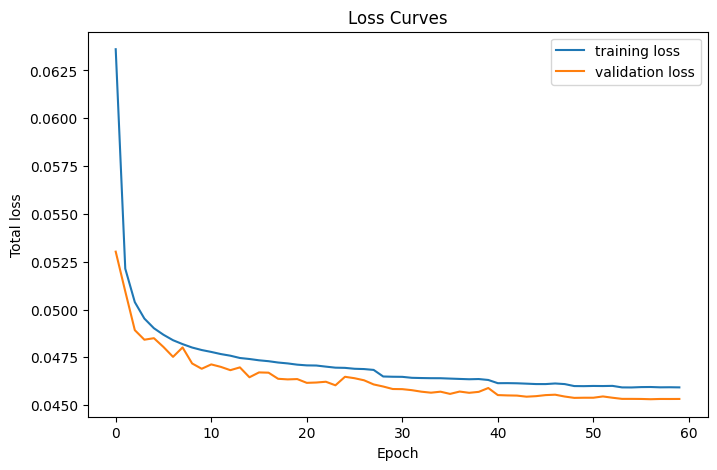

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='training loss')
plt.plot(history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('Loss Curves')
plt.legend()
plt.show()


## Step 15 - Look at one prediction

The loss does not tell me everything so I must get it to make a prediction.

For spectra, I should also plot the input, the real target mask, and the model prediction.

This lets me see if the model is actually finding peak-shaped regions.


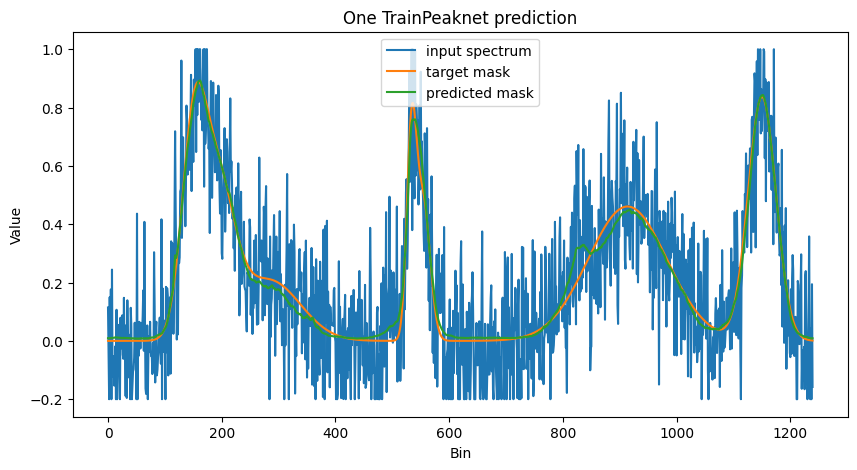

In [15]:
# Again in evaluation mode 
model.eval()

# Get one batch of validation data to visualize the predictions
xb, yb, valid_bins = next(iter(val_loader))
xb = xb.to(device)
yb = yb.to(device)
valid_bins = valid_bins.to(device)

# Just making a prediction so no gradients needed
with torch.no_grad():
    prediction = model(xb)

# Picking an example from the batch 
example_index = 10

# Work out the real length so the padded part is not plotted
real_length = int(valid_bins[example_index, 0].sum().item())

# Extract the input spectrum, target mask, and predicted mask for the chosen example and move them to CPU for plotting
input_spectrum = xb[example_index, 0, :real_length].cpu().numpy()
target_mask = yb[example_index, 0, :real_length].cpu().numpy()
predicted_mask = prediction[example_index, 0, :real_length].cpu().numpy()

plt.figure(figsize=(10, 5))
plt.plot(input_spectrum, label='input spectrum')
plt.plot(target_mask, label='target mask')
plt.plot(predicted_mask, label='predicted mask')
plt.xlabel('Bin')
plt.ylabel('Value')
plt.title('One TrainPeaknet prediction')
plt.legend()
plt.show()


## Step 16 - Check the saved best model

The training loop has already saved the best model.

This cell just checks where it was saved.


In [16]:
print('Best model path:', best_checkpoint_path)
print('Best validation loss:', best_val_loss)
print('File exists:', os.path.exists(best_checkpoint_path))


Best model path: /home/exxley/Documents/Peaknet/Models/checkpoints/peaknet_20260815_011311.pth
Best validation loss: 0.045307782639705
File exists: True
